# Ethical Challenges and AI Bias — Live Demo Notebook

**Purpose:** This notebook demonstrates how AI bias can appear in a simple machine learning workflow and how we can start diagnosing and mitigating it.

The demo is designed for a **mixed academic audience**. It does not require advanced ML knowledge, but it also includes enough depth for IT/data-oriented participants.

## Learning goals

You should understand that:

1. A model can be accurate and still unfair.
2. Bias may appear even when a protected attribute is removed.
3. Proxy variables can carry hidden social information.
4. Fairness must be measured, not assumed.
5. Mitigation improves fairness but may introduce trade-offs.


In [1]:
# Core imports
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Synthetic scenario

We simulate a university admission / scholarship screening system.

The model predicts whether a candidate should be accepted based on:

- exam score,
- previous academic performance,
- interview score,
- school quality index,
- access to extracurricular activities,
- region type: urban or rural.

The protected/socially sensitive attribute in this simplified example is **region type**.

This is not a perfect representation of reality. It is a controlled educational scenario showing how bias can enter the system.


In [2]:
def generate_biased_admission_data(n=5000, seed=42):
    rng = np.random.default_rng(seed)

    # Group variable: 0 = rural, 1 = urban
    region = rng.choice([0, 1], size=n, p=[0.4, 0.6])

    # Structural inequality encoded in data generation
    school_quality = rng.normal(loc=55 + 15 * region, scale=10, size=n)
    school_quality = np.clip(school_quality, 20, 100)

    extracurricular_access = rng.normal(loc=45 + 25 * region, scale=15, size=n)
    extracurricular_access = np.clip(extracurricular_access, 0, 100)

    # Candidate ability is not directly observed
    latent_ability = rng.normal(loc=65, scale=12, size=n)

    # Observed indicators are affected by both ability and opportunity
    exam_score = (
        0.65 * latent_ability
        + 0.25 * school_quality
        + rng.normal(0, 8, size=n)
    )
    exam_score = np.clip(exam_score, 0, 100)

    academic_record = (
        0.70 * latent_ability
        + 0.20 * school_quality
        + rng.normal(0, 7, size=n)
    )
    academic_record = np.clip(academic_record, 0, 100)

    # Interview contains subjective bias against rural candidates
    interview_score = (
        0.55 * latent_ability
        + 0.25 * extracurricular_access
        + 5 * region
        + rng.normal(0, 10, size=n)
    )
    interview_score = np.clip(interview_score, 0, 100)

    # Historical acceptance decision:
    # not only merit-based; it also reflects unequal opportunity and subjective assessment.
    logit = (
        -8.0
        + 0.045 * exam_score
        + 0.035 * academic_record
        + 0.035 * interview_score
        + 0.010 * school_quality
        + 0.012 * extracurricular_access
        + 0.50 * region
    )

    probability = 1 / (1 + np.exp(-logit))
    accepted = rng.binomial(1, probability)

    df = pd.DataFrame({
        "region": region,
        "region_label": np.where(region == 1, "urban", "rural"),
        "school_quality": school_quality,
        "extracurricular_access": extracurricular_access,
        "exam_score": exam_score,
        "academic_record": academic_record,
        "interview_score": interview_score,
        "accepted": accepted
    })

    return df

df = generate_biased_admission_data()
df.head()


,region,region_label,school_quality,extracurricular_access,exam_score,academic_record,interview_score,accepted
0,1,urban,59.010754,92.621158,54.057432,45.813735,46.484403,0
1,1,urban,64.586856,100.000000,46.722464,58.078122,41.714954,0
2,1,urban,72.720011,73.518857,50.765597,61.558678,73.639849,1
3,1,urban,63.716800,60.423562,61.132188,71.046397,59.396349,1
4,0,rural,52.216336,41.675401,68.212676,65.294014,66.905629,0


## 2. Basic data check

Before training a model, we inspect how outcomes differ across groups.

This is the first ethical checkpoint: **do groups have different acceptance rates?**


In [3]:
summary = (
    df.groupby("region_label")
    .agg(
        n=("accepted", "size"),
        acceptance_rate=("accepted", "mean"),
        exam_score_mean=("exam_score", "mean"),
        interview_score_mean=("interview_score", "mean"),
        school_quality_mean=("school_quality", "mean"),
        extracurricular_mean=("extracurricular_access", "mean")
    )
    .round(3)
)

summary


,n,acceptance_rate,exam_score_mean,interview_score_mean,school_quality_mean,extracurricular_mean
region_label,,,,,,
rural,2023,0.362,56.650,47.314,54.825,44.851
urban,2977,0.657,60.207,58.497,70.063,69.868


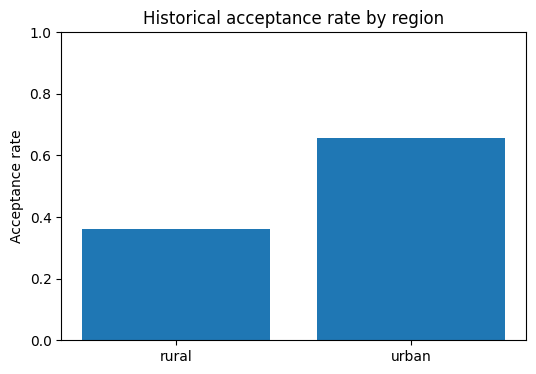

In [4]:
acceptance_rates = df.groupby("region_label")["accepted"].mean()

plt.figure(figsize=(6, 4))
plt.bar(acceptance_rates.index, acceptance_rates.values)
plt.ylabel("Acceptance rate")
plt.title("Historical acceptance rate by region")
plt.ylim(0, 1)
plt.show()


### Talking point

Is this difference caused by the model, by the data, or by the real world?

The answer is uncomfortable: often, it is all three.


## 3. Train a baseline model

We train a simple logistic regression model.

First, we include all variables, including `region`.

This reflects a risky real-world situation: the model can explicitly use group membership.


In [5]:
features_with_region = [
    "region",
    "school_quality",
    "extracurricular_access",
    "exam_score",
    "academic_record",
    "interview_score"
]

X = df[features_with_region]
y = df["accepted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

model_with_region = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

model_with_region.fit(X_train, y_train)

pred = model_with_region.predict(X_test)
proba = model_with_region.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, pred), 3))
print("Precision:", round(precision_score(y_test, pred), 3))
print("Recall:", round(recall_score(y_test, pred), 3))


Accuracy: 0.737
Precision: 0.753
Recall: 0.761


## 4. Fairness metrics

We compute simple group fairness indicators.

For each group we calculate:

- **Selection rate**: how often the model predicts acceptance.
- **True positive rate / recall**: among truly accepted candidates, how often the model correctly predicts acceptance.
- **False positive rate**: among truly rejected candidates, how often the model incorrectly predicts acceptance.

We also calculate:

- **Demographic parity difference**: difference in selection rates.
- **Equal opportunity difference**: difference in true positive rates.


In [1]:
def fairness_report(data, y_true, y_pred, group_col="region_label", positive_label=1):
    temp = data.copy()
    temp["y_true"] = np.asarray(y_true)
    temp["y_pred"] = np.asarray(y_pred)

    rows = []

    for group, g in temp.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(g["y_true"], g["y_pred"], labels=[0, 1]).ravel()

        selection_rate = g["y_pred"].mean()
        tpr = tp / (tp + fn) if (tp + fn) else np.nan
        fpr = fp / (fp + tn) if (fp + tn) else np.nan
        accuracy = accuracy_score(g["y_true"], g["y_pred"])

        rows.append({
            "group": group,
            "n": len(g),
            "selection_rate": selection_rate,
            "true_positive_rate": tpr,
            "false_positive_rate": fpr,
            "accuracy": accuracy
        })

    report = pd.DataFrame(rows).round(3)

    dp_diff = report["selection_rate"].max() - report["selection_rate"].min()
    eo_diff = report["true_positive_rate"].max() - report["true_positive_rate"].min()

    return report, round(dp_diff, 3), round(eo_diff, 3)

test_data = X_test.copy()
test_data["region_label"] = np.where(test_data["region"] == 1, "urban", "rural")

report_with_region, dp_with_region, eo_with_region = fairness_report(test_data, y_test, pred)

print(report_with_region, dp_with_region, eo_with_region)


NameError: name 'X_test' is not defined

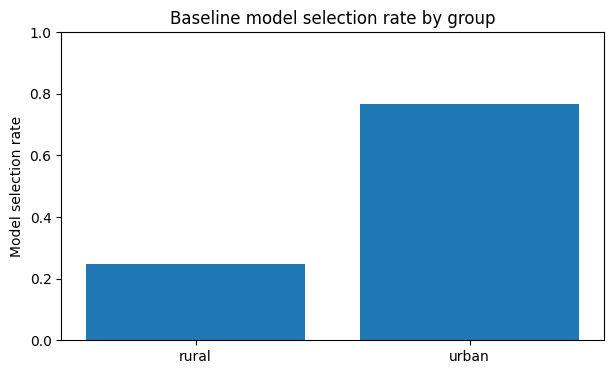

Demographic parity difference: 0.519
Equal opportunity difference: 0.437


In [7]:
plt.figure(figsize=(7, 4))
plt.bar(report_with_region["group"], report_with_region["selection_rate"])
plt.ylabel("Model selection rate")
plt.title("Baseline model selection rate by group")
plt.ylim(0, 1)
plt.show()

print("Demographic parity difference:", dp_with_region)
print("Equal opportunity difference:", eo_with_region)


### Talking point

A model may show good overall accuracy, but its behavior may differ strongly across groups.

This is why **aggregate performance is not enough**.


## 5. Naive mitigation: remove the protected attribute

A common reaction is:

> Just remove the sensitive attribute.

Now we remove `region` and train the model again.

The question is: **does this solve the problem?**


In [8]:
features_without_region = [
    "school_quality",
    "extracurricular_access",
    "exam_score",
    "academic_record",
    "interview_score"
]

X = df[features_without_region]
y = df["accepted"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

model_without_region = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

model_without_region.fit(X_train2, y_train2)

pred2 = model_without_region.predict(X_test2)

print("Accuracy:", round(accuracy_score(y_test2, pred2), 3))
print("Precision:", round(precision_score(y_test2, pred2), 3))
print("Recall:", round(recall_score(y_test2, pred2), 3))


Accuracy: 0.731
Precision: 0.748
Recall: 0.752


In [9]:
# Recreate group labels for the same test indices
test_data2 = df.loc[X_test2.index, ["region_label"]].copy()

report_without_region, dp_without_region, eo_without_region = fairness_report(
    test_data2, y_test2, pred2
)

report_without_region, dp_without_region, eo_without_region


(   group    n  selection_rate  true_positive_rate  false_positive_rate  \
 0  rural  646           0.285               0.504                0.155   
 1  urban  854           0.734               0.857                0.491   
 
    accuracy  
 0     0.718  
 1     0.740  ,
 0.449,
 0.353)

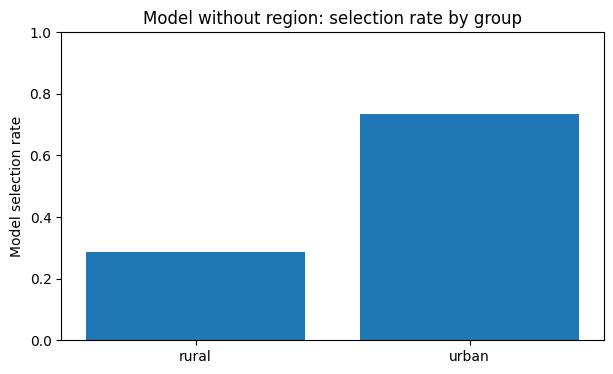

Demographic parity difference: 0.449
Equal opportunity difference: 0.353


In [10]:
plt.figure(figsize=(7, 4))
plt.bar(report_without_region["group"], report_without_region["selection_rate"])
plt.ylabel("Model selection rate")
plt.title("Model without region: selection rate by group")
plt.ylim(0, 1)
plt.show()

print("Demographic parity difference:", dp_without_region)
print("Equal opportunity difference:", eo_without_region)


### Interpretation

Removing the protected attribute may reduce direct discrimination, but it often does **not** remove bias.

Why?

Because other variables can act as **proxies**:

- school quality,
- extracurricular access,
- location-related infrastructure,
- historical opportunity patterns.

This is one of the most important lessons in AI ethics.


## 6. Simple mitigation: threshold adjustment

Now we demonstrate a simple fairness intervention.

Instead of using the same decision threshold for both groups, we apply a more supportive threshold for the disadvantaged group.

This is not a universal solution. It is a teaching example showing that fairness is a design decision, not a natural property of a model.


In [11]:
# Get probabilities from the model without region
proba2 = model_without_region.predict_proba(X_test2)[:, 1]

thresholds = {
    "urban": 0.50,
    "rural": 0.42
}

test_data3 = df.loc[X_test2.index, ["region_label"]].copy()
pred3 = np.array([
    1 if p >= thresholds[group] else 0
    for p, group in zip(proba2, test_data3["region_label"])
])

print("Accuracy:", round(accuracy_score(y_test2, pred3), 3))
print("Precision:", round(precision_score(y_test2, pred3), 3))
print("Recall:", round(recall_score(y_test2, pred3), 3))

report_adjusted, dp_adjusted, eo_adjusted = fairness_report(
    test_data3, y_test2, pred3
)

report_adjusted, dp_adjusted, eo_adjusted


Accuracy: 0.724
Precision: 0.722
Recall: 0.793


(   group    n  selection_rate  true_positive_rate  false_positive_rate  \
 0  rural  646           0.402               0.642                0.261   
 1  urban  854           0.734               0.857                0.491   
 
    accuracy  
 0     0.703  
 1     0.740  ,
 0.332,
 0.215)

In [12]:
comparison = pd.DataFrame({
    "model": [
        "Baseline with region",
        "Without region",
        "Threshold adjusted"
    ],
    "accuracy": [
        accuracy_score(y_test, pred),
        accuracy_score(y_test2, pred2),
        accuracy_score(y_test2, pred3)
    ],
    "demographic_parity_difference": [
        dp_with_region,
        dp_without_region,
        dp_adjusted
    ],
    "equal_opportunity_difference": [
        eo_with_region,
        eo_without_region,
        eo_adjusted
    ]
}).round(3)

comparison


,model,accuracy,demographic_parity_difference,equal_opportunity_difference
0,Baseline with region,0.737,0.519,0.437
1,Without region,0.731,0.449,0.353
2,Threshold adjusted,0.724,0.332,0.215


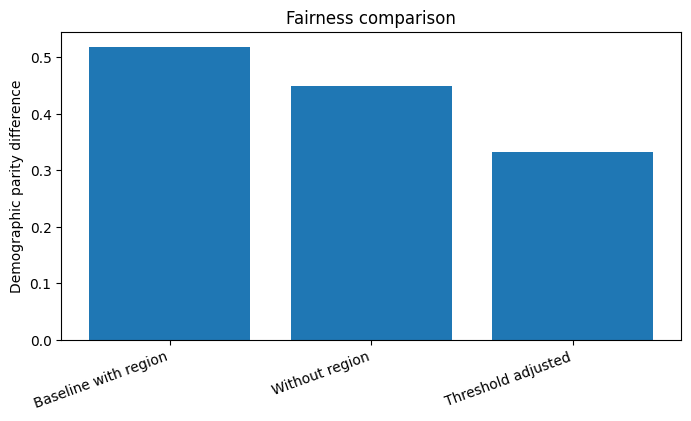

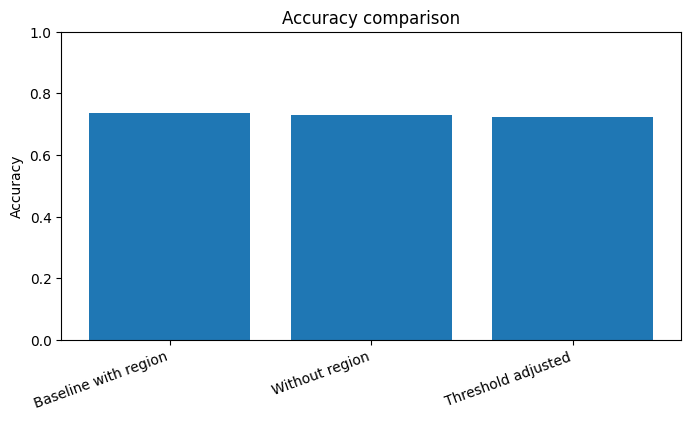

In [13]:
plt.figure(figsize=(8, 4))
plt.bar(comparison["model"], comparison["demographic_parity_difference"])
plt.ylabel("Demographic parity difference")
plt.title("Fairness comparison")
plt.xticks(rotation=20, ha="right")
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(comparison["model"], comparison["accuracy"])
plt.ylabel("Accuracy")
plt.title("Accuracy comparison")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.show()


## 7. Discussion prompts

Use these questions with participants:

1. Is the threshold adjustment fair or unfair?
2. Who should decide what fairness means?
3. Should a university prioritize equal acceptance rates, equal opportunity, or individual ranking?
4. Is accuracy enough when decisions affect people?
5. What documentation should be required before deployment?
6. Would this system be high-risk under the EU AI Act?


## 8. Key takeaway

A practical AI bias audit should never stop at model accuracy.

A minimal responsible workflow should include:

- subgroup performance analysis,
- fairness metrics,
- proxy variable analysis,
- documentation of assumptions,
- human oversight,
- post-deployment monitoring.

**Final message for the audience:**

> AI bias is not only a technical bug. It is a governance problem.
